In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/raw/Enron.csv")

# 198 sujets manquants -> chaîne vide
df["subject"] = df["subject"].fillna("")

# Texte complet de l'email = sujet + corps
df["text"] = df["subject"] + " " + df["body"]

# Libellé lisible pour les graphiques
df["classe"] = df["label"].map({0: "Non-spam", 1: "Spam"})

df.head()

,subject,body,label,text,classe
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0,"hpl nom for may 25 , 2001 ( see attached file ...",Non-spam
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0,re : nom / actual vols for 24 th - - - - - - -...,Non-spam
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0,"enron actuals for march 30 - april 1 , 201 est...",Non-spam
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0,"hpl nom for may 30 , 2001 ( see attached file ...",Non-spam
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0,"hpl nom for june 1 , 2001 ( see attached file ...",Non-spam


In [2]:
for lab in [0, 1]:
    print(f"========== label = {lab} ==========")
    for i in range(3):
        ex = df[df["label"] == lab].sample(1, random_state=i).iloc[0]
        print("Sujet :", ex["subject"])
        print("Corps :", ex["body"][:250].replace("\r\n", " "), "\n")

========== label = 0 ==========
Sujet : tw expansion
Corps : - - - - - - - - - - - - - - - - - - - - - - forwarded by lorraine lindberg / et & s / enron on 02 / 15 / 2001 08 : 01 am - - - - - - - - - - - - - - - - - - - - - - - - - - - drew fossum 02 / 14 / 2001 04 : 38 pm to : susan scott / et & s / enron  

Sujet : ets and corporate change control items
Corps : the following items were discussed in this week ' s ets and corporate change control . . . july 11 beginning today and lasting through 7 / 13 at 5 : 00 p . m . , the corporate print team will make changes and verify the following printers resolve t 

Sujet : start date : 1 / 8 / 02 ; hourahead hour : 18 ;
Corps : start date : 1 / 8 / 02 ; hourahead hour : 18 ; no ancillary schedules awarded . no variances detected . log messages : parsing file - - > > o : \\ portland \\ westdesk \\ california scheduling \\ iso final schedules \\ 2002010818 . txt 

========== label = 1 ==========
Sujet : = ? iso - 8859 - 1 ? q ? c = ecalis _ v 

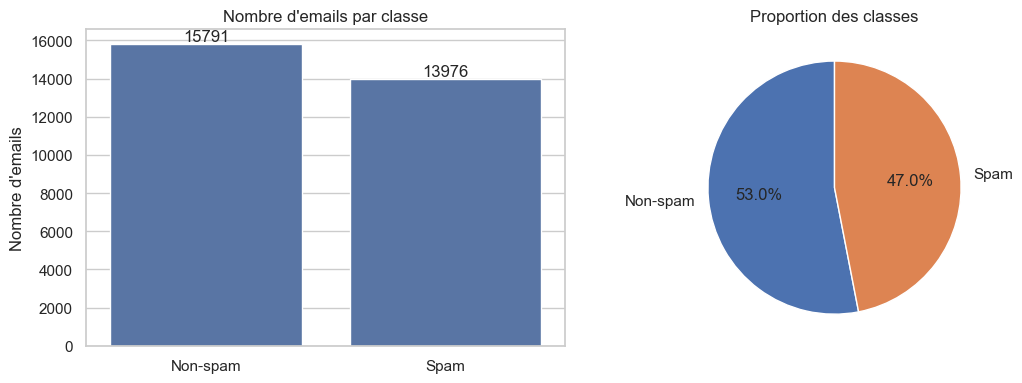

In [3]:
counts = df["classe"].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=df, x="classe", order=counts.index, ax=ax[0])
ax[0].set_title("Nombre d'emails par classe")
ax[0].set_xlabel("")
ax[0].set_ylabel("Nombre d'emails")
for p in ax[0].patches:
    ax[0].annotate(int(p.get_height()),
                   (p.get_x() + p.get_width() / 2, p.get_height()),
                   ha="center", va="bottom")

ax[1].pie(counts, labels=counts.index, autopct="%1.1f%%", startangle=90)
ax[1].set_title("Proportion des classes")

plt.tight_layout()
plt.savefig("../images/02_repartition_classes.png", dpi=150)
plt.show()

In [4]:
df["nb_caracteres"] = df["text"].str.len()
df["nb_mots"] = df["text"].str.split().str.len()

print(df.groupby("classe")[["nb_caracteres", "nb_mots"]].describe().T)

classe                    Non-spam          Spam
nb_caracteres count   15791.000000  13976.000000
              mean     1659.208726   1368.880509
              std      5456.730970   1984.193426
              min        16.000000      5.000000
              25%       353.000000    375.000000
              50%       812.000000    677.000000
              75%      1709.000000   1453.250000
              max    230135.000000  31393.000000
nb_mots       count   15791.000000  13976.000000
              mean      348.399088    267.293575
              std      1078.774186    385.041981
              min         3.000000      2.000000
              25%        74.000000     74.000000
              50%       175.000000    140.000000
              75%       369.000000    283.000000
              max     45450.000000   8397.000000


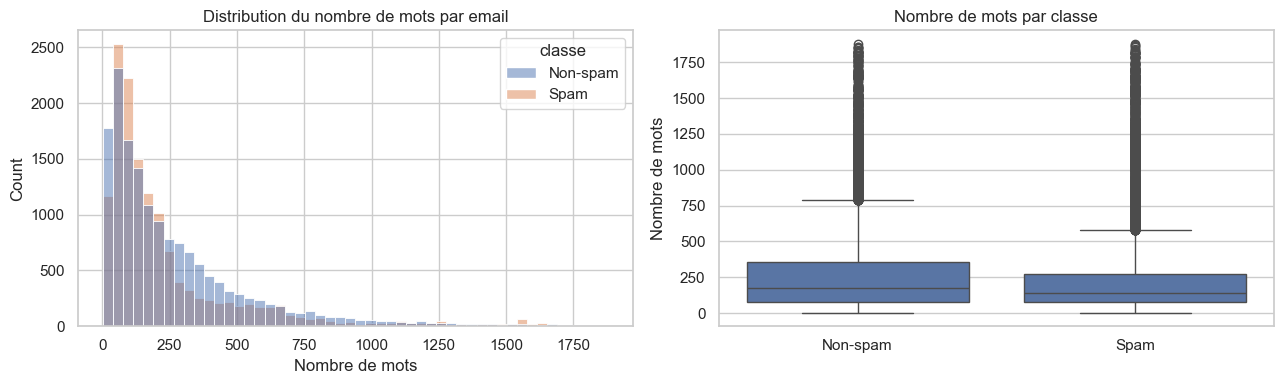

In [5]:
# On coupe les 1 % d'emails les plus longs pour que le graphique soit lisible
limite = df["nb_mots"].quantile(0.99)
sub = df[df["nb_mots"] <= limite]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sns.histplot(data=sub, x="nb_mots", hue="classe", bins=50, ax=ax[0])
ax[0].set_title("Distribution du nombre de mots par email")
ax[0].set_xlabel("Nombre de mots")

sns.boxplot(data=sub, x="classe", y="nb_mots", ax=ax[1])
ax[1].set_title("Nombre de mots par classe")
ax[1].set_xlabel("")
ax[1].set_ylabel("Nombre de mots")

plt.tight_layout()
plt.savefig("../images/02_longueur_emails.png", dpi=150)
plt.show()

In [6]:
print("Corps vides :", (df["body"].str.strip() == "").sum())
print("Sujets vides :", (df["subject"].str.strip() == "").sum())
print("Doublons sur le texte :", df.duplicated(subset=["text"]).sum())
print("\nDoublons par classe :")
print(df[df.duplicated(subset=["text"], keep=False)]["classe"].value_counts())

Corps vides : 0
Sujets vides : 198
Doublons sur le texte : 0

Doublons par classe :
Series([], Name: count, dtype: int64)


In [9]:
%pip install --only-binary :all: wordcloud

Note: you may need to restart the kernel to use updated packages.


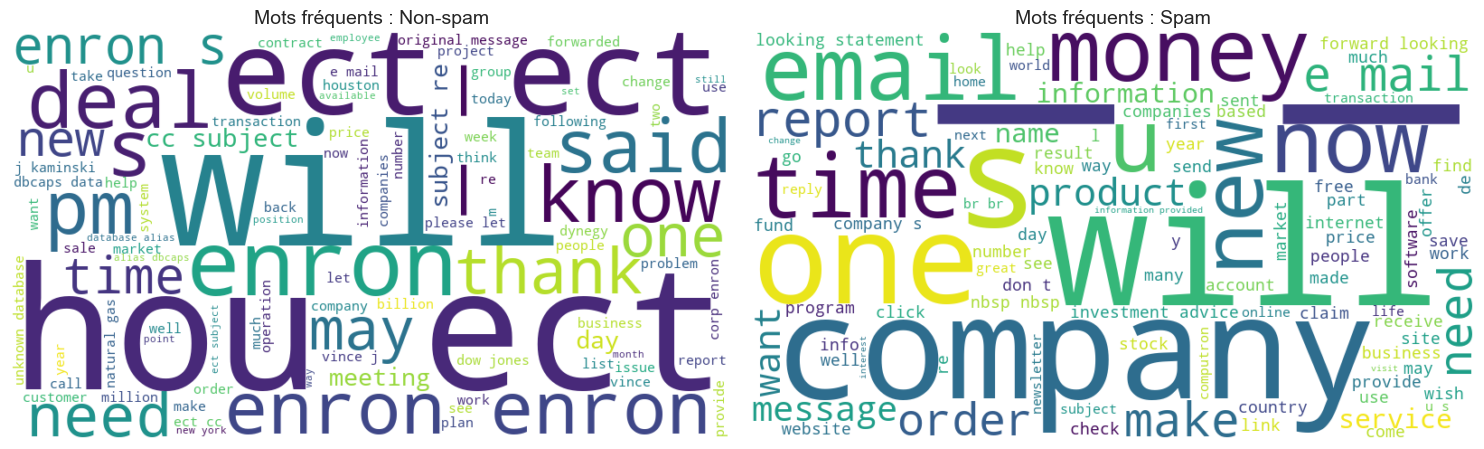

In [10]:
from wordcloud import WordCloud, STOPWORDS

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

for a, lab, titre in zip(ax, [0, 1], ["Non-spam", "Spam"]):
    textes = df[df["label"] == lab]["text"].sample(5000, random_state=42)
    wc = WordCloud(width=800, height=450, background_color="white",
                   stopwords=STOPWORDS, max_words=100).generate(" ".join(textes))
    a.imshow(wc, interpolation="bilinear")
    a.set_title(f"Mots fréquents : {titre}", fontsize=14)
    a.axis("off")

plt.tight_layout()
plt.savefig("../images/02_nuages_de_mots.png", dpi=150)
plt.show()

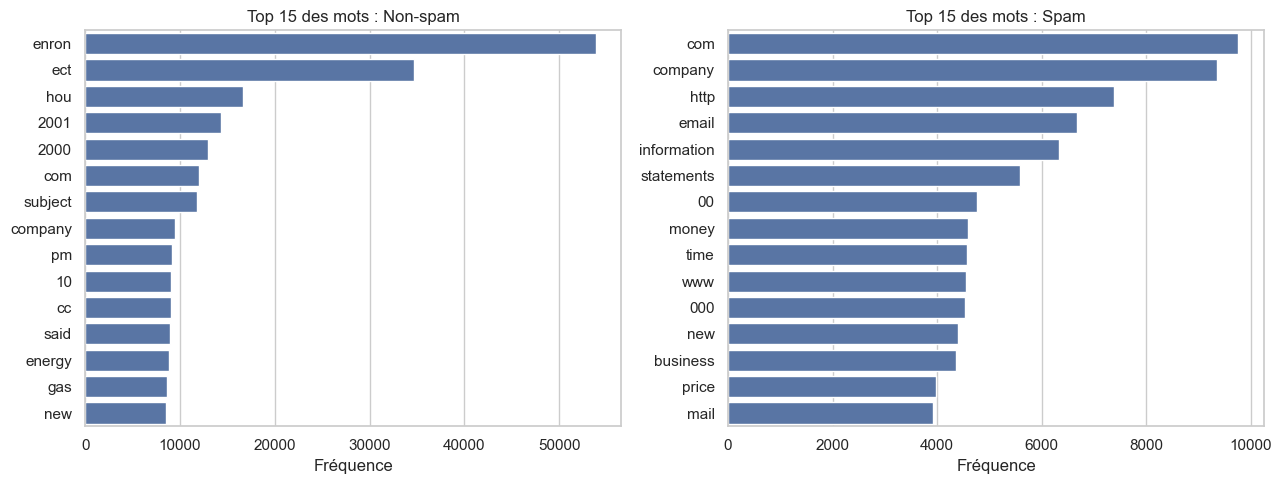

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

def top_mots(textes, n=15):
    cv = CountVectorizer(stop_words="english", max_features=5000)
    X = cv.fit_transform(textes)
    freq = np.asarray(X.sum(axis=0)).ravel()
    mots = np.array(cv.get_feature_names_out())
    idx = freq.argsort()[::-1][:n]
    return pd.DataFrame({"mot": mots[idx], "frequence": freq[idx]})

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, lab, titre in zip(ax, [0, 1], ["Non-spam", "Spam"]):
    top = top_mots(df[df["label"] == lab]["text"])
    sns.barplot(data=top, x="frequence", y="mot", ax=a)
    a.set_title(f"Top 15 des mots : {titre}")
    a.set_xlabel("Fréquence")
    a.set_ylabel("")

plt.tight_layout()
plt.savefig("../images/02_top_mots.png", dpi=150)
plt.show()